## Dans ce travail pratique, nous explorons la régression softmax et les MLP avec les données MNIST

### <font color='blue'> Importer les librairies </font>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt

# Reproductibilité
torch.manual_seed(42)

# detecter et utiliser l'accelerateur pour votre machine
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Matplotlib is building the font cache; this may take a moment.


Using mps device


### <font color='blue'> Charger et explorer le jeu de données. Sélectionner un sous-ensemble pour l'entraînement. </font>

In [3]:
# Chargement via torchvision (équivalent de tf.keras.datasets.mnist)
from torchvision import datasets, transforms

transform = transforms.ToTensor()  # normalise automatiquement les pixels dans [0, 1]

mnist_train_full = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test       = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Taille train complet : {len(mnist_train_full)}')
print(f'Taille test          : {len(mnist_test)}')

100.0%
100.0%
100.0%
100.0%

Taille train complet : 60000
Taille test          : 10000


In [4]:
# Explorer le jeu de données
x_train_full = mnist_train_full.data.float()  # shape (60000, 28, 28)
y_train_full = mnist_train_full.targets                 # shape (60000,)  — entiers long
x_test       = mnist_test.data.float()
y_test       = mnist_test.targets

print(f'X_train shape : {x_train_full.shape}')
print(f'Y_train shape : {y_train_full.shape}')
print(f'X_test  shape : {x_test.shape}')
print(f'Y_test  shape : {y_test.shape}')

# NOTE PyTorch : les labels restent des entiers (Long) — pas de one-hot encoding comme on le fait manuellement dans tensorflow.
# CrossEntropyLoss s'en charge nativement.

X_train shape : torch.Size([60000, 28, 28])
Y_train shape : torch.Size([60000])
X_test  shape : torch.Size([10000, 28, 28])
Y_test  shape : torch.Size([10000])


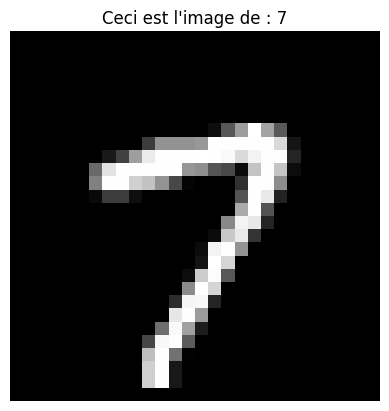

In [5]:
# Visualiser une image
index_img = 103
plt.imshow(x_train_full[index_img], cmap='gray')
plt.title(f"Ceci est l'image de : {y_train_full[index_img].item()}")
plt.axis('off')
plt.show()

In [6]:
# Choisir un nombre limité d'images pour l'entraînement
num_train_img = 10000

x_train_reduit = x_train_full[:num_train_img]   # (10000, 28, 28)
y_train_reduit = y_train_full[:num_train_img]   # (10000,)

# Séparation train / validation (80 % / 20 %) — équivalent de validation_split=0.2
n_val   = int(0.2 * num_train_img)
n_train = num_train_img - n_val

x_train = x_train_reduit[:n_train]
y_train = y_train_reduit[:n_train]
x_val   = x_train_reduit[n_train:]
y_val   = y_train_reduit[n_train:]

print(f'Train : {x_train.shape}  Val : {x_val.shape}')

Train : torch.Size([8000, 28, 28])  Val : torch.Size([2000, 28, 28])


### <font color='blue'> Créer le modèle MLP </font>

Architecture : **Flatten → Linear(784→64) → ReLU → Linear(64→32) → ReLU → Linear(32→10)**

La dernière couche produit des **logits bruts** (pas de softmax). `CrossEntropyLoss` applique
log-softmax en interne, ce qui est numériquement plus stable.

In [7]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron pour la classification MNIST.
    Architecture
    ------------
    Input (N, 28, 28) → Flatten → [Linear → ReLU] × 2 → Linear (logits)
    """

    def __init__(self, input_dim: int = 784,
                 num_classes: int = 10) -> None:
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Flatten(),                        # (N, 28, 28) → (N, 784)
            nn.Linear(input_dim, 64),            # (N, 784)   → (N, 64)
            nn.ReLU(),
            nn.Linear(64, 32),                   # (N, 64)    → (N, 32)
            nn.ReLU(),
            nn.Linear(32, num_classes),          # (N, 32)    → (N, 10) logits
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(x)


# Instanciation et affichage
mon_model = MLP(input_dim=28 * 28, num_classes=10).to(device)
print(mon_model)

n_params = sum(p.numel() for p in mon_model.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params:,}')

MLP(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)

Paramètres entraînables : 52,650


### <font color='blue'> Définir la fonction de coût et l'optimiseur </font>

| Keras (original)         | PyTorch (équivalent)                       |
|--------------------------|-----------------------------------------|
| `categorical_crossentropy` avec one-hot | `nn.CrossEntropyLoss()` avec labels entiers |
| `SGD(lr=0.01, momentum=0.0)` | `optim.SGD(lr=0.01, momentum=0.0)` |

In [8]:
lr       = 0.01
momentum = 0.0

criterion = nn.CrossEntropyLoss()                              # log-softmax + NLL en une passe
optimizer = optim.SGD(mon_model.parameters(), lr=lr, momentum=momentum)

### <font color='blue'> Entraîner et tester le modèle </font>

In [9]:
# Préparer les DataLoaders PyTorch
batch_size  = 32
nombre_epochs = 20   # 4000 était trop élevé dans l'original (early-stop implicite)

train_dataset = TensorDataset(x_train.to(device), y_train.to(device))
val_dataset   = TensorDataset(x_val.to(device),   y_val.to(device))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

In [10]:
# Boucle d'entraînement — équivalent de model.fit() dans tensorflow
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(nombre_epochs):

    # Phase d'entraînement 
    mon_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()            # 1. Réinitialiser les gradients
        logits = mon_model(X_batch)      # 2. Passe forward
        loss   = criterion(logits, y_batch)  # 3. Calculer la perte
        loss.backward()                  # 4. Rétropropagation
        optimizer.step()                 # 5. Mise à jour des poids

        running_loss += loss.item() * X_batch.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == y_batch).sum().item()
        total        += X_batch.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # Phase de validation
    mon_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():               # Pas de calcul de gradient en validation
        for X_batch, y_batch in val_loader:
            logits  = mon_model(X_batch)
            loss    = criterion(logits, y_batch)
            val_loss_sum += loss.item() * X_batch.size(0)
            preds         = logits.argmax(dim=1)
            val_correct  += (preds == y_batch).sum().item()
            val_total    += X_batch.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    # Enregistrer l'historique
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f'Epoch {epoch+1:3d}/{nombre_epochs}  '
          f'loss={train_loss:.4f}  acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

Epoch   1/20  loss=2.2650  acc=0.2401  val_loss=2.2093  val_acc=0.3610
Epoch   2/20  loss=2.0879  acc=0.4662  val_loss=1.9122  val_acc=0.5345
Epoch   3/20  loss=1.6421  acc=0.5988  val_loss=1.3544  val_acc=0.6885
Epoch   4/20  loss=1.0860  acc=0.7459  val_loss=0.8996  val_acc=0.7625
Epoch   5/20  loss=0.7517  acc=0.8039  val_loss=0.6963  val_acc=0.7935
Epoch   6/20  loss=0.5957  acc=0.8345  val_loss=0.6059  val_acc=0.8190
Epoch   7/20  loss=0.5117  acc=0.8544  val_loss=0.5352  val_acc=0.8520
Epoch   8/20  loss=0.4546  acc=0.8728  val_loss=0.5147  val_acc=0.8615
Epoch   9/20  loss=0.4157  acc=0.8845  val_loss=0.4632  val_acc=0.8740
Epoch  10/20  loss=0.3853  acc=0.8945  val_loss=0.4422  val_acc=0.8815
Epoch  11/20  loss=0.3639  acc=0.8981  val_loss=0.4289  val_acc=0.8805
Epoch  12/20  loss=0.3455  acc=0.9035  val_loss=0.4182  val_acc=0.8835
Epoch  13/20  loss=0.3316  acc=0.9093  val_loss=0.4048  val_acc=0.8845
Epoch  14/20  loss=0.3183  acc=0.9123  val_loss=0.3914  val_acc=0.8940
Epoch 

### <font color='blue'> Définir une fonction utilitaire pour visualiser la courbe de coût et la performance </font>

Clés d'historique disponibles : ['loss', 'accuracy', 'val_loss', 'val_accuracy']


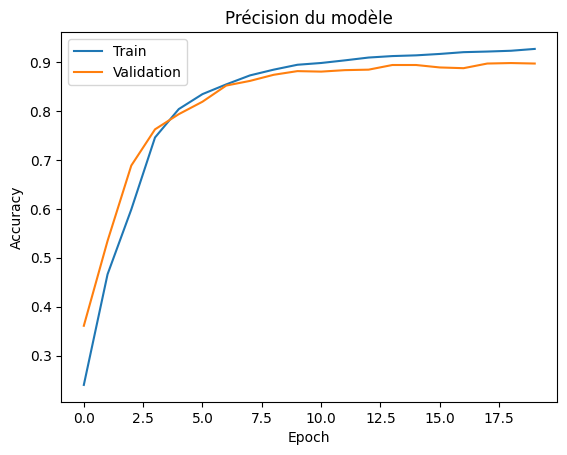

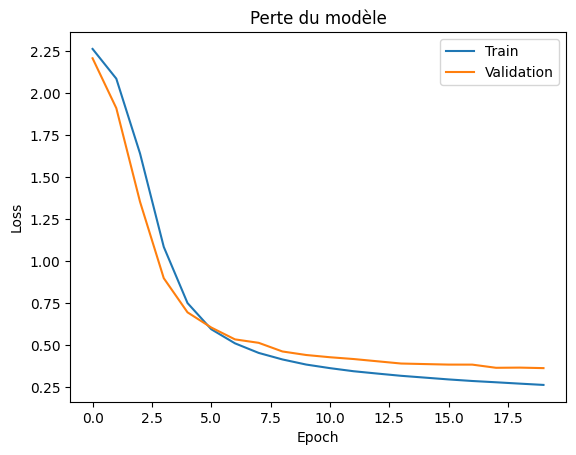

In [11]:
def plot_training_history(history: dict) -> None:
    """Affiche l'évolution de la précision et de la perte (train / validation)."""

    plt.figure()
    plt.plot(history['accuracy'],     label='Train')
    plt.plot(history['val_accuracy'], label='Validation')
    plt.title('Précision du modèle')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.show()

    plt.figure()
    plt.plot(history['loss'],     label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title('Perte du modèle')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.show()


print(f'Clés d\'historique disponibles : {list(history.keys())}')
plot_training_history(history)

### <font color='blue'> Évaluer le modèle </font>

Équivalent de `model.evaluate()` en Keras.

In [12]:
def evaluate(model: nn.Module, X: torch.Tensor, y: torch.Tensor,
             criterion: nn.Module, batch_size: int = 256) -> tuple:
    """Retourne (loss, accuracy) sur un jeu de données complet."""
    loader = DataLoader(TensorDataset(X.to(device), y.to(device)),
                        batch_size=batch_size, shuffle=False)
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item() * X_batch.size(0)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
            total      += X_batch.size(0)
    return total_loss / total, correct / total


r1 = evaluate(mon_model, x_train_reduit, y_train_reduit, criterion)
r2 = evaluate(mon_model, x_train_full,   y_train_full,   criterion)
r3 = evaluate(mon_model, x_test,         y_test,         criterion)

print(f'Train réduit → loss={r1[0]:.4f}  acc={r1[1]:.4f}')
print(f'Train complet → loss={r2[0]:.4f}  acc={r2[1]:.4f}')
print(f'Test          → loss={r3[0]:.4f}  acc={r3[1]:.4f}')

Train réduit → loss=0.2776  acc=0.9213
Train complet → loss=0.3335  acc=0.9020
Test          → loss=0.3211  acc=0.9052


### <font color='blue'> Tester avec quelques images </font>

Prédiction du modèle : 4
Valeur correcte      : 4
Probabilités des classes :
[[6.7549401e-05 4.0366667e-04 3.8867362e-04 9.7119398e-03 7.5798631e-01
  3.5363816e-02 8.9100935e-04 9.8556750e-02 2.9097763e-03 9.3720496e-02]]


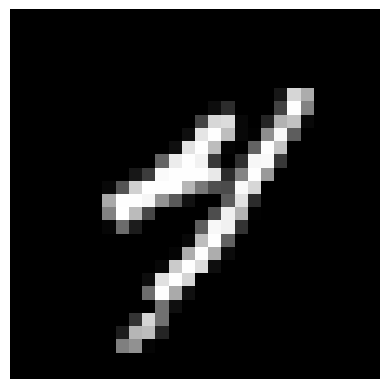

In [13]:
def predict_single(model: nn.Module, image: torch.Tensor) -> tuple:
    """Retourne (classe prédite, probabilités softmax) pour une image (28, 28)."""
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))   # (1, 28, 28) → logits
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
    return int(probs.argmax()), probs


index_img = 9669
image     = x_test[index_img]

y_hat, softmax_output = predict_single(mon_model, image)

print(f'Prédiction du modèle : {y_hat}')
print(f'Valeur correcte      : {y_test[index_img].item()}')
print(f'Probabilités des classes :\n{softmax_output}')

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

### <font color='blue'> Visualiser plusieurs images et leurs prédictions </font>

20 images à visualiser


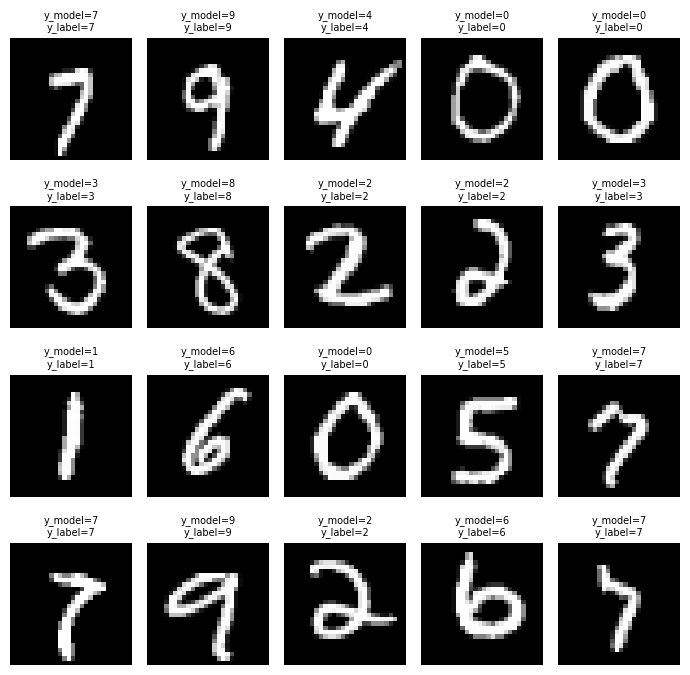

In [14]:
def visualize_multiple_images(model: nn.Module,
                              images: torch.Tensor,
                              labels: torch.Tensor) -> None:
    """Affiche images + prédictions (rouge si erreur, noir si correct)."""
    n    = images.shape[0]
    cols = 5
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(7, 7))
    axes = axes.flatten()

    model.eval()
    with torch.no_grad():
        # Prédictions en batch — plus efficace qu'image par image
        logits = model(images.to(device))
        preds  = logits.argmax(dim=1).cpu()

    for i in range(n):
        ax    = axes[i]
        color = 'black' if preds[i] == labels[i] else 'red'
        ax.imshow(images[i], cmap='gray')
        ax.set_title(f'y_model={preds[i].item()}\ny_label={labels[i].item()}',
                     color=color, fontsize=7)
        ax.axis('off')

    # Masquer les axes vides éventuels
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


start_id = 3040
end_id   = start_id + 20
images   = x_test[start_id:end_id]
etiquettes = y_test[start_id:end_id]

print(f'{images.shape[0]} images à visualiser')
visualize_multiple_images(mon_model, images, etiquettes)